info: flattening network topology
(node) p
(list) pe
(list) pi
(edge) pe_p: (list) pe -> (node) p
(edge) pi_p: (list) pi -> (node) p
22336


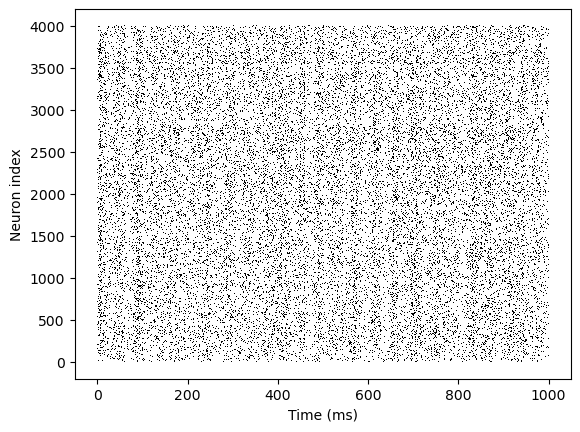

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import Neuron, PSP, shared

from sango.backend import SimBrian
from brian2 import ms

# Define new model classes
@dataclass
class CUBA(Neuron):
    model: str = 'CUBA'
    v: float = 0.0
    ge: float = 0.0
    gi: float = 0.0
    Vt: float = shared(10.0)
    Vr: float = shared(0.0)
    El: float = shared(5.0)
    taum: float = shared(20.0)
    taue: float = shared(5.0)
    taui: float = shared(10.0)
    tref: float = shared(5.0)

@dataclass
class PSPe(PSP):
    model: str = 'PSPe'

@dataclass
class PSPi(PSP):
    model: str = 'PSPi'

# Define model registry with how the new models map to the backend
brian_registry = {'CUBA': {'graph_type': 'neuron',
                           'model_eqs' : '''
                                         dv/dt  = (ge+gi-(v-El))/taum : 1 (unless refractory)
                                         dge/dt = -ge/taue : 1
                                         dgi/dt = -gi/taui : 1
                                         ''',
                           'method'    : 'exact',
                           'threshold' : 'v>Vt',
                           'reset'     : 'v=Vr',
                           'refractory': 'tref',
                           'events'    : {},
                           'state': {'v':      {'dsl': 'v',     'default': -60.0},
                                     'ge':     {'dsl': 'ge',    'default': 0.0},
                                     'gi':     {'dsl': 'gi',    'default': 0.0}},
                           'param': {'Vt':     {'dsl': 'Vt',    'default': -50.0},
                                     'Vr':     {'dsl': 'Vr',    'default': -60.0},
                                     'El':     {'dsl': 'El',    'default': -49.0},
                                     'taum':   {'dsl': 'taum',  'default': 20.0, 'unit': 'ms'},
                                     'taue':   {'dsl': 'taue',  'default': 5.0,  'unit': 'ms'},
                                     'taui':   {'dsl': 'taui',  'default': 10.0, 'unit': 'ms'},
                                     'tref':   {'dsl': 'tref',  'default': 5.0,  'unit': 'ms'}}},
                  'PSPe': {'graph_type': 'synapse',
                           'model_eqs' : 'weight : 1',
                           'on_pre'    : 'ge+=weight',
                           'state': {'delay':    {'dsl': 'delay',  'default': 1.0, 'unit': 'ms'},
                                     'weight':   {'dsl': 'weight', 'default': 1.0}}},
                  'PSPi': {'graph_type': 'synapse',
                           'model_eqs' : 'weight : 1',
                           'on_pre'    : 'gi+=weight',
                           'state': {'delay':    {'dsl': 'delay',  'default': 1.0, 'unit': 'ms'},
                                     'weight':   {'dsl': 'weight', 'default': 1.0}}}
                 }

# Helper function for random edges
def rand_edges(s1, s2, prob):
    index = np.random.choice(
        range(s1*s2), size=int(s1*s2*prob),
        replace=False)
    edges = []
    for idx in index:
        i = idx // s2
        j = idx % s2
        edges.append((i,j))
    return edges

# CUBA Neuron model
Vt = -50.0
Vr = -60.0
El = -49.0
cuba_neuron = CUBA(Vt=Vt, Vr=Vr, El=El)

# Create network
net = Network()
net.p = NodeGroup(cuba_neuron, 4000)
net.p.v = Vr + np.random.uniform(size=(4000)) * (Vt - Vr)

# Split population into excitatory and inhibitory subsets
net.pe = NodeList(net.p[:3200])
net.pi = NodeList(net.p[3200:])

# Generate random connectivity
net.pe_p = EdgeGroup(net.pe, net.p, PSPe(weight=(60*0.27/10)),
                     edges=rand_edges(3200, 4000, 0.02))
net.pi_p = EdgeGroup(net.pi, net.p, PSPi(weight=(-20*4.5/10)),
                     edges=rand_edges(800, 4000, 0.02))

# Build network
net.build()
print(net)

# Simulate network in Brian
sim = SimBrian(net)
sim.model_registry.update(brian_registry)
sim.tstep = 0.1*ms # Brian 2 default

# Compile and run
sim.compile()
sim.run(10000) # 1s

# Plot spike list similarly to Brian 2
# Using eventplot with this many spikes suffers from aliasing
spike_list = sim.get_spikes()
spike_table = [[],[]] # t, n
for n, spikes in enumerate(spike_list):
    for t in spikes:
        spike_table[0].append(t)
        spike_table[1].append(n)
plt.plot(spike_table[0], spike_table[1], ',k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
print(len(spike_table[0]))

22539


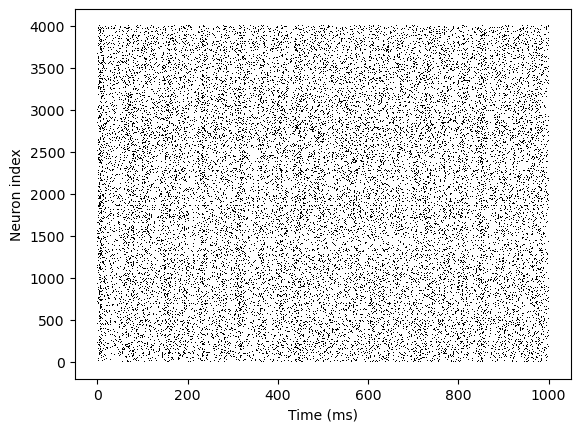

In [2]:
# Reference code from: https://brian2.readthedocs.io/en/stable/examples/CUBA.html
from brian2 import *

import time

taum = 20*ms
taue = 5*ms
taui = 10*ms
Vt = -50*mV
Vr = -60*mV
El = -49*mV

eqs = '''
dv/dt  = (ge+gi-(v-El))/taum : volt (unless refractory)
dge/dt = -ge/taue : volt
dgi/dt = -gi/taui : volt
'''

P = NeuronGroup(4000, eqs, threshold='v>Vt', reset='v = Vr', refractory=5*ms,
                method='exact')
P.v = 'Vr + rand() * (Vt - Vr)'
P.ge = 0*mV
P.gi = 0*mV

we = (60*0.27/10)*mV # excitatory synaptic weight (voltage)
wi = (-20*4.5/10)*mV # inhibitory synaptic weight
Ce = Synapses(P, P, on_pre='ge += we')
Ci = Synapses(P, P, on_pre='gi += wi')
Ce.connect('i<3200', p=0.02)
Ci.connect('i>=3200', p=0.02)

s_mon = SpikeMonitor(P)

run(1 * second)

plot(s_mon.t/ms, s_mon.i, ',k')
xlabel('Time (ms)')
ylabel('Neuron index')
print(len(s_mon.t))